# **Project 1 AUTOENCODERS**
## **DEEP LEARNING**

    Daniela de la Torre Gallo
    Aissa Berenice González Fosado
    Clara Paola Aguilar Casillas

### **Dataset**
We constructed a custom dataset of 1,000 glasses images using web scraping to collect the required samples. To ensure consistency and improve training performance, all images share the same orientation and have a white background. 

This standardization helps reduce unnecessary variability, which is especially important given the relatively small dataset size used for training the autoencoder. 

# **Data Preparation**

In [2]:
# libraries
import random
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Input, Flatten, Dense, Reshape, Conv2D, MaxPooling2D, Conv2DTranspose, UpSampling2D
from tensorflow.keras.models import Model

### **Resizing**
All images were resized to 32×32 pixels with three RGB channels to ensure a uniform input shape for the model. 

Total images: 1000
All images resized to: (32, 32)


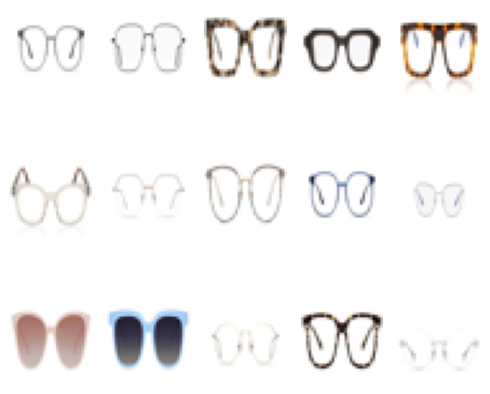

In [3]:
# getting the images
data_dir = Path("../data/raw")
image_paths = image_paths = (
    list(data_dir.glob("*.jpeg")) +
    list(data_dir.glob("*.jpg"))
)
print("Total images:", len(image_paths))

# target size
SIZE = (32, 32)

# resize all images into a list
images_resized = [Image.open(p).resize(SIZE) for p in image_paths]

print("All images resized to:", SIZE)

# show sample
sample = random.sample(images_resized, 15)

fig, axes = plt.subplots(3, 5, figsize=(5, 5))
axes = axes.flatten()

for ax, img in zip(axes, sample):
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

### **Normalization**

We are converting the image arrays to `float32` and normalizing them by dividing by 255, since RGB color images have pixel values ranging from 0 to 255. This scales the data to the [0, 1] range, which improves numerical stability and helps the autoencoder train more efficiently.

In [4]:
# Convert the list of images to a NumPy array for splitting
images_np = np.array(images_resized)

# Normalize to [0, 1]
images_norm = tf.cast(images_np, tf.float32) / 255.0
images_norm = images_norm.numpy()          # back to numpy for sklearn split

### **Train Test and Validation split**
The resized images are converted to a NumPy array and split into 80% training, 10% validation, and 10% test sets with a fixed random_state for reproducibility. For our experiments, the training set learns from these samples, the validation set tunes and monitors the model, and the test set evaluates final performance and is held for the final inspection.

In [5]:
# 80 / 10 / 10 split

# First cut: 80 % train, 20 % temp
X_train, X_temp = train_test_split(images_norm, test_size=0.20, random_state=42)
# Second cut: split the 20 % temp equally into val and test
X_val, X_test   = train_test_split(X_temp,      test_size=0.50, random_state=42)

print(f'Train : {X_train.shape}')   # (800, 32, 32, 3)
print(f'Val   : {X_val.shape}')     # (100, 32, 32, 3)
print(f'Test  : {X_test.shape}')    # (100, 32, 32, 3)

Train : (800, 32, 32, 3)
Val   : (100, 32, 32, 3)
Test  : (100, 32, 32, 3)


Funtion to show our reconstructions and loss

In [6]:
def show_reconstructions(model, data, n=8, title=''):
    """Plot n original / reconstructed pairs from data."""
    reconstructed = model.predict(data[:n])
    fig, axes = plt.subplots(2, n, figsize=(n * 1.8, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for i in range(n):
        axes[0, i].imshow(data[i])
        axes[0, i].axis('off')
        axes[0, i].set_title('Original', fontsize=7)
        axes[1, i].imshow(np.clip(reconstructed[i], 0, 1))
        axes[1, i].axis('off')
        axes[1, i].set_title('Reconstructed', fontsize=7)
    plt.tight_layout()
    plt.show()


def plot_loss(history, title='Training Loss'):
    """Plot training and validation loss curves."""
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'],     label='Train loss')
    plt.plot(history.history['val_loss'], label='Val loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

# **Model 1**
## **Deep** (Fully-Connected) **Autoencoder**

The model first flattens the image into a 1-D vector, progressively reduces dimensionality through stacked Dense layers, compresses the representation into an 8-dimensional latent vector, and then mirrors the architecture to reconstruct the original image.

This was our simplest AE yet we had to keep making changes to it, since we got with millions of parameters when we started, this was fixed reducing the dimensionality of our first layer and our latent space.

**Architecture**

**Encoder**
| Layer   | Type               | Output Shape | Description                               |
| ------- | ------------------ | ------------ | ----------------------------------------- |
| Input   | Input              | (32, 32, 3)  | Original image                            |
| Flatten | Flatten            | (3072)       | Converts image into a 1D vector (32×32×3) |
| Dense   | 128 neurons (ReLU) | (128)        | First compression stage                   |
| Dense   | 64 neurons (ReLU)  | (64)         | Further compression                       |
| Dense   | 16 neurons (ReLU)  | (16)         | High-level compact features               |

**Latent Space**

| Layer        | Type      | Output Shape | Description                                  |
| ------------ | --------- | ------------ | -------------------------------------------- |
| Latent Space | 8 neurons | (8)          | Final compressed representation (bottleneck) |


**Decoder**

| Layer   | Type                   | Output Shape | Description                         |
| ------- | ---------------------- | ------------ | ----------------------------------- |
| Dense   | 16 neurons (ReLU)      | (16)         | Start expanding from latent space   |
| Dense   | 64 neurons (ReLU)      | (64)         | Continue expansion                  |
| Dense   | 128 neurons (ReLU)     | (128)        | Recover higher dimensional features |
| Dense   | 3072 neurons (Sigmoid) | (3072)       | Reconstruct all pixel values (0–1)  |
| Reshape | Reshape                | (32, 32, 3)  | Convert vector back to image shape  |

In [7]:
# Deep Fully-Connected Autoencoder

encoder_input = Input(shape=(32, 32, 3), name='encoder_input')

x = Flatten()(encoder_input) # flatten image to 1D vector

#  Encoder
x = Dense(128, activation='relu')(x) #compress to 128 
x = Dense(64,  activation='relu')(x) #compress to 64 
x = Dense(16,  activation='relu')(x) #compress to 16 

# Latent Space
latent_space = Dense(8, name='latent_space')(x) # latent space of 8

# Decoder
x = Dense(16, activation='relu')(latent_space) # expand back to 16
x = Dense(64, activation='relu')(x) # expand back to 64
x = Dense(128, activation='relu')(x) # expand back to 128

x = Dense(32 * 32 * 3, activation='sigmoid')(x) # final vector for all pixels (0-1)

decoder_output = Reshape((32, 32, 3))(x) # reshape back to (32,32,3) image

deep_ae = Model(encoder_input, decoder_output, name='DeepAutoencoder') # assemble model

deep_ae.compile(optimizer='adam', loss='binary_crossentropy')

deep_ae.summary()

Model: "DeepAutoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3072)           │       396,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 32, 32, 3)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 808,616 (3.08 MB)

 Trainable params: 808,616 (3.08 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train the model
history_deep = deep_ae.fit(
    X_train, X_train,             
    epochs=50,
    batch_size=32,
    shuffle=True,
    validation_data=(X_val, X_val)
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.3420 - val_loss: 0.2022
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1932 - val_loss: 0.1918
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1888 - val_loss: 0.1900
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1870 - val_loss: 0.1884
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1841 - val_loss: 0.1870
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1817 - val_loss: 0.1852
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1800 - val_loss: 0.1826
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1756 - val_loss: 0.1785
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1728 - val_loss: 0.1770
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1714 - val_loss: 0.1757
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1706 - val_loss: 0.1752
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1

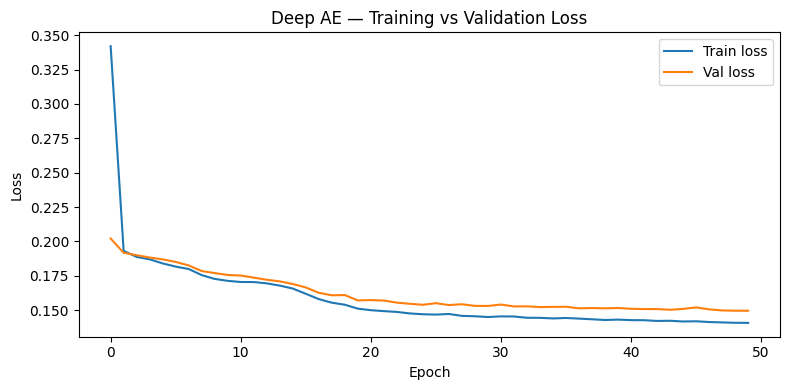

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


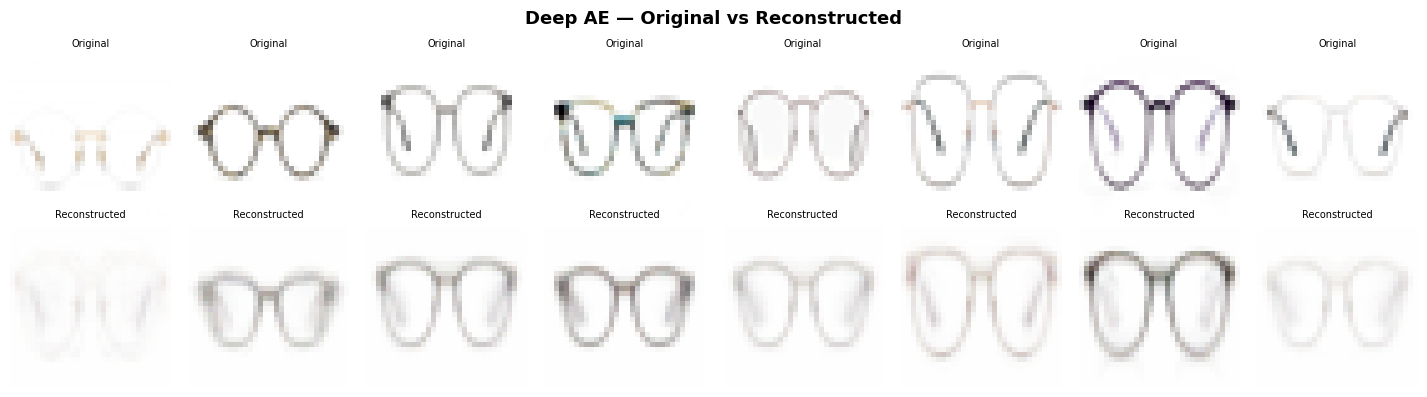

In [9]:
# Plot loss curves and reconstructions
plot_loss(history_deep, title='Deep AE — Training vs Validation Loss')
show_reconstructions(deep_ae, X_test, title='Deep AE — Original vs Reconstructed')

# **Model 2**
## **Convolutional Autoencoder** (CAE)

For this project, a convolutional autoencoder (CAE) is a more suitable choice than a fully connected architecture. Dense layers process every pixel independently and do not account for the spatial relationships that define images. As a result, they often require a large number of parameters to learn even simple visual patterns. 

We saw a huge jump from 808,616 parameters (That were already very hard to get this low), down to 75,651 parameters, making this Convolutional autoencoder much more efficient.

Convolutional layers are specifically designed for image data: they share weights across spatial locations and learn local patterns such as edges, textures, and shapes. This not only reduces the total number of trainable parameters but also allows the model to better preserve structural information during reconstruction. Consequently, a CAE typically produces sharper and more visually coherent outputs while remaining computationally efficient for images of this size and we noticed it on our graphs below.

### **Architecture**

**Encoder**
| Layer | Output shape | Description |
|---|---|---|
| Conv2D 32 × (3×3), ReLU, same | 32×32×32 | Detects low-level features (edges, colours); `same` padding keeps spatial dims |
| MaxPool2D 2×2 | 16×16×32 | Halves spatial resolution; keeps the strongest activations |
| Conv2D 64 × (3×3), ReLU, same | 16×16×64 | Learns higher-level patterns |
| MaxPool2D 2×2 | 8×8×64 | Further downsampling → **latent space** |

**Decoder**
| Layer | Output shape | Description |
|---|---|---|
| Conv2DTranspose 64 × (3×3), ReLU, same | 8×8×64 | Learnable upsampling (better than bilinear) |
| UpSampling2D 2×2 | 16×16×64 | Doubles spatial resolution |
| Conv2DTranspose 32 × (3×3), ReLU, same | 16×16×32 | Refines features |
| UpSampling2D 2×2 | 32×32×32 | Restores original resolution |
| Conv2DTranspose 3 × (3×3), **Sigmoid**, same | 32×32×3 | Final RGB output in [0,1] |


In [10]:
encoder_input = Input(shape=(32, 32, 3))

#  Encoder
# First conv block : detect low-level features (edges, colour blobs)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)  # (32,32,32)
x = MaxPooling2D((2, 2))(x)                                      # (16,16,32)

# Second conv block : detect higher-level patterns
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)    # (16,16,64)
encoded = MaxPooling2D((2, 2))(x)                                # (8,8,64)  latent space (bottleneck)

# Decoder
# Mirror block 2
x = Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(encoded)  # (8,8,64)
x = UpSampling2D((2, 2))(x)                                                   # (16,16,64)

# Mirror block 1
x = Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)        # (16,16,32)
x = UpSampling2D((2, 2))(x)                                                   # (32,32,32)

# Output layer : 3 channels with sigmoid to match [0,1] normalisation
decoded = Conv2DTranspose(3, (3, 3), activation='sigmoid', padding='same')(x) # (32,32,3)

conv_ae = Model(encoder_input, decoded, name='Conv_AE')
conv_ae.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                loss='binary_crossentropy')
conv_ae.summary()

Model: "Conv_AE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 64)       │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 3)      │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Train the model
history_conv = conv_ae.fit(
    X_train, X_train,
    epochs=50,
    batch_size=32,
    shuffle=True,
    validation_data=(X_val, X_val)
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.3525 - val_loss: 0.2553
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.2274 - val_loss: 0.2039
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.1861 - val_loss: 0.1803
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.1738 - val_loss: 0.1698
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.1627 - val_loss: 0.1614
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.1564 - val_loss: 0.1571
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.1502 - val_loss: 0.1505
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.1456 - val_loss: 0.1466
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.1417 - val_loss: 0.1448
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.1390 - val_loss: 0.1408
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.1363 - val_loss: 0.1385
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.1

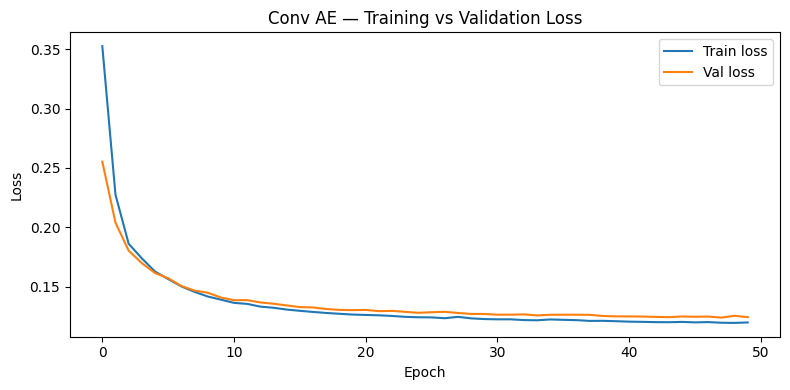

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


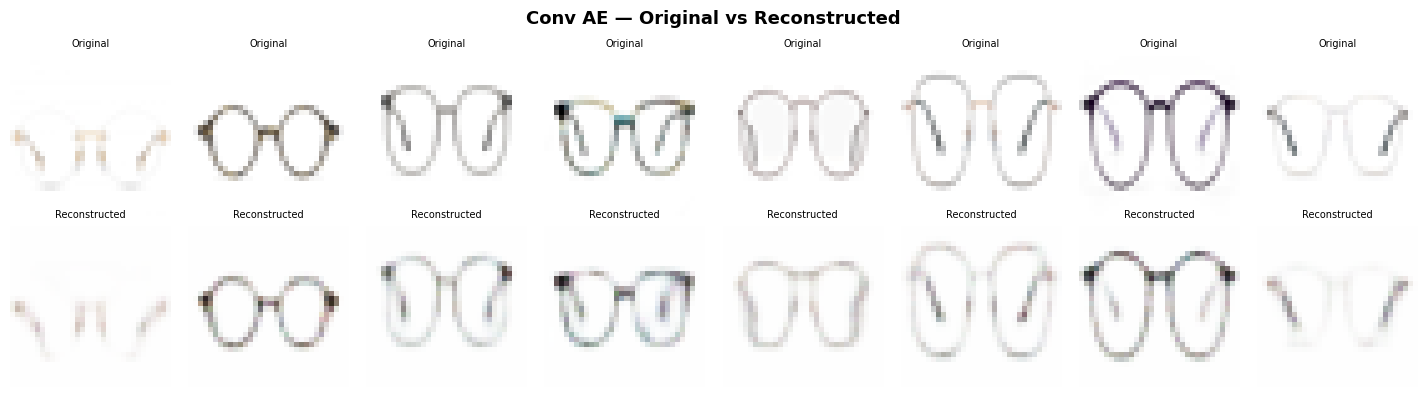

In [12]:
# Plot loss curves and reconstructions
plot_loss(history_conv, title='Conv AE — Training vs Validation Loss')
show_reconstructions(conv_ae, X_test, title='Conv AE — Original vs Reconstructed')

# **Model 3**
## **Denoising Autoencoder** (DAE)


On our project, a denoising variant of the convolutional autoencoder is a natural extension. A denoising autoencoder is trained by **corrupting the input** with random noise and asking the network to reconstruct the **clean** original. This forces the encoder to learn truly meaningful structure rather than an identity mapping, acting as a regulariser and improving feature quality.

### **Noise strategy**
We corrupted the input with Gaussian noise with standard deviation stddev = 0.15. After adding noise, values are clipped to the [0,1] range so the network always sees valid pixel intensities.The chosen noise level is large enough to produce clearly corrupted examples while preserving the underlying structure the model must learn to recover; this encourages the encoder to extract robust, generalizable features

### **Architecture**
Identical to the Convolutional AE we did above the only change is that noisy images are passed as input while clean images remain the target. This demonstrates how the same architecture behaves differently depending on the training objective.

| Layer    | Dimensions   | Description                                                                                                     |
| ------------ | -------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------- |
| Input        | 32×32×3                                                                                                  | Noisy RGB image supplied to the network during training                                                     |
| Encoder      | 32×32×32 → (MaxPool) → 16×16×32 → 16×16×64 → (MaxPool) → 8×8×64                                          | Convolutional downsampling that learns local features and compresses spatial information into a compact map |
| Latent / Map | 8×8×64 (encoder output)                                                                                  | Encoded spatial feature map (the “latent” representation for CAE style)                                     |
| Decoder      | 8×8×64 → ConvTranspose/Up → 16×16×64 → ConvTranspose/Up → 32×32×32 → ConvTranspose(3, sigmoid) → 32×32×3 | Symmetric upsampling and refinement to reconstruct the RGB image in [0,1]                                   |
| Output       | 32×32×3                                                                                                  | Clean image target (ground-truth)                                                                           |

In [13]:
# ADD GAUSSIAN NOISE to training and validation inputs
noise_factor = 0.15

# tf.random.normal generates Gaussian noise with mean=0, stddev=noise_factor
X_train_noisy = X_train + tf.random.normal(shape=X_train.shape, mean=0.0,
                                            stddev=noise_factor, dtype=tf.float32)
X_val_noisy   = X_val   + tf.random.normal(shape=X_val.shape,   mean=0.0,
                                            stddev=noise_factor, dtype=tf.float32)
X_test_noisy  = X_test  + tf.random.normal(shape=X_test.shape,  mean=0.0,
                                            stddev=noise_factor, dtype=tf.float32)

# Clip to valid [0,1] range — noise can push values outside this range
X_train_noisy = tf.clip_by_value(X_train_noisy, 0.0, 1.0).numpy()
X_val_noisy   = tf.clip_by_value(X_val_noisy,   0.0, 1.0).numpy()
X_test_noisy  = tf.clip_by_value(X_test_noisy,  0.0, 1.0).numpy()

In [14]:
# Same architecture as the Model 2
encoder_input = Input(shape=(32, 32, 3))

# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2))(x)    # (8,8,64) latent space (bottleneck)

# Decoder
x = Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2DTranspose(3, (3, 3), activation='sigmoid', padding='same')(x)

denoise_ae = Model(encoder_input, decoded, name='Denoising_AE')
denoise_ae.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                   loss='binary_crossentropy')
denoise_ae.summary()

Model: "Denoising_AE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 8, 8, 64)       │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 16, 16, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 32, 32, 3)      │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Train on NOISY inputs, but the TARGET is the CLEAN image
history_denoise = denoise_ae.fit(
    X_train_noisy, X_train,
    epochs=50,
    batch_size=32,
    shuffle=True,
    validation_data=(X_val_noisy, X_val)
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.3424 - val_loss: 0.2579
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.2300 - val_loss: 0.2046
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.1878 - val_loss: 0.1817
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.1727 - val_loss: 0.1712
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.1660 - val_loss: 0.1654
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.1596 - val_loss: 0.1609
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.1560 - val_loss: 0.1562
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.1512 - val_loss: 0.1522
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.1475 - val_loss: 0.1502
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.1453 - val_loss: 0.1474
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.1425 - val_loss: 0.1441
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.1

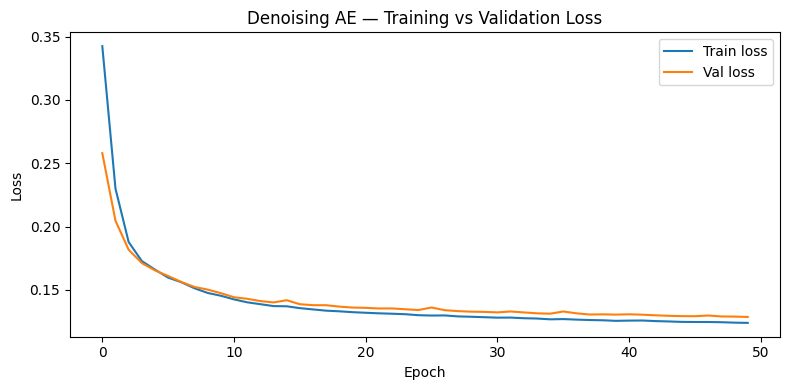

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step


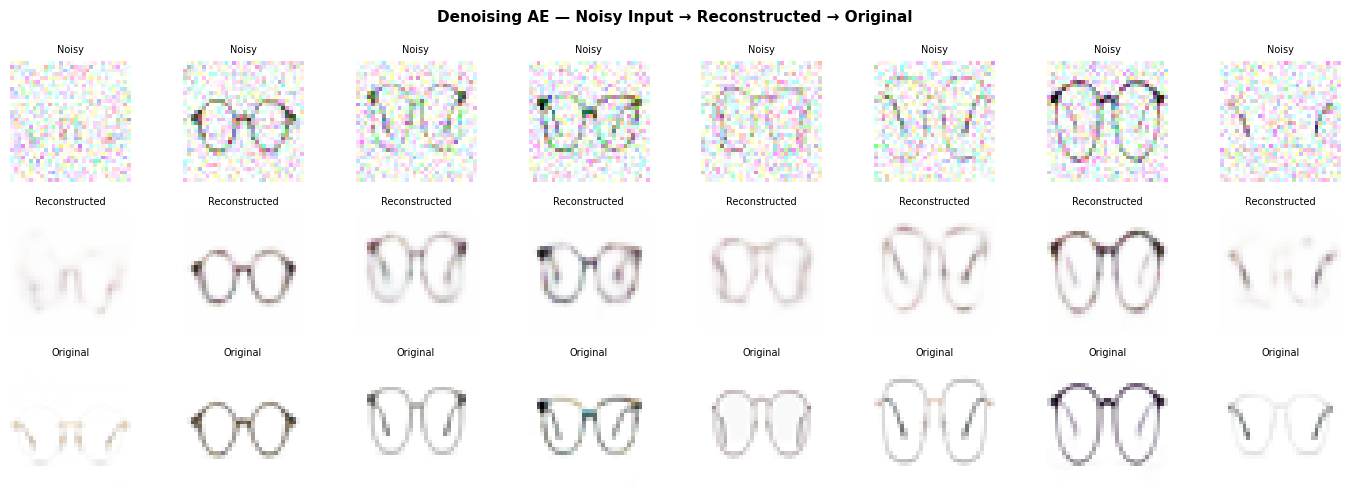

In [16]:
# Plot loss curves and reconstructions, but the reconsruction also shows the noised image

plot_loss(history_denoise, title='Denoising AE — Training vs Validation Loss')

reconstructed_clean = denoise_ae.predict(X_test_noisy[:8])

fig, axes = plt.subplots(3, 8, figsize=(14, 5))
fig.suptitle('Denoising AE — Noisy Input → Reconstructed → Original', fontsize=11, fontweight='bold')
for i in range(8):
    axes[0, i].imshow(X_test_noisy[i])
    axes[0, i].axis('off')
    axes[0, i].set_title('Noisy', fontsize=7)

    axes[1, i].imshow(np.clip(reconstructed_clean[i], 0, 1))
    axes[1, i].axis('off')
    axes[1, i].set_title('Reconstructed', fontsize=7)

    axes[2, i].imshow(X_test[i])
    axes[2, i].axis('off')
    axes[2, i].set_title('Original', fontsize=7)

plt.tight_layout()
plt.show()

# **Model 4**
## Variational Autoencoder (VAE)

A Variational Autoencoder is a generative neural network that learns to compress images into a probabilistic latent space and then reconstruct them. Instead of mapping each image to a single fixed point, it learns a mean and variance that define a distribution. By sampling from this distribution and decoding it, the model can generate new images that resemble the training data. The loss function combines reconstruction error (to keep outputs realistic) and KL divergence (to organize the latent space into a smooth normal distribution).

Since our project consists of generation new images of the glasses too, not just reconstructing the images. The structured latent space allows us to sample random vectors and create new designs that follow the patterns learned during training.

This worked well for the glasses dataset because glasses share consistent shapes and symmetry, which convolutional layers capture effectively from what we saw on earlier experiments. The 16-dimensional latent space was enough to represent key variations (frame shape, thickness, style) without overfitting, and the KL regularization ensured that sampling produced realistic new glasses instead of noise.

### **Architecture**

| Layer     | Type                          | Output Shape | Description                         |
| --------- | ----------------------------- | ------------ | ----------------------------------- |
| Input     | Input                         | (32,32,3)    | Glasses image                       |
| Conv1     | Conv2D (32 filters, stride 2) | (16,16,32)   | Extracts low-level features         |
| Conv2     | Conv2D (64 filters, stride 2) | (8,8,64)     | Learns deeper visual patterns       |
| Flatten   | Flatten                       | (4096)       | Converts feature map to vector      |
| Dense     | Dense (128)                   | (128)        | High-level representation           |
| z_mean    | Dense (16)                    | (16)         | Mean of latent distribution         |
| z_log_var | Dense (16)                    | (16)         | Log variance of latent distribution |
| Sampling  | Custom Layer                  | (16)         | Samples latent vector z             |

**Latent Space**

| Component         | Dimension | Purpose                                            |
| ----------------- | --------- | -------------------------------------------------- |
| Latent Vector (z) | 16        | Compressed probabilistic representation of glasses |


**Decoder**

| Layer   | Type                           | Output Shape | Description                    |
| ------- | ------------------------------ | ------------ | ------------------------------ |
| Input   | Input                          | (16)         | Sampled latent vector          |
| Dense   | Dense (4096)                   | (4096)       | Expands latent space           |
| Reshape | Reshape                        | (8,8,64)     | Converts vector to feature map |
| Deconv1 | Conv2DTranspose (64, stride 2) | (16,16,64)   | Upsampling                     |
| Deconv2 | Conv2DTranspose (32, stride 2) | (32,32,32)   | Upsampling                     |
| Output  | Conv2D (3 filters, sigmoid)    | (32,32,3)    | Final generated image          |



In [49]:
# hyperparameters and values we need for later
img_shape = (32, 32, 3)
latent_dim = 16
batch_size = 32
epochs = 50
save_path = Path("../data/processed")
save_path.mkdir(parents=True, exist_ok=True)

Sampling layer 

In [50]:
# Sampling layer (reparameterization trick)
class Sampling(tf.keras.layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

In [51]:
# encoder 
encoder_inputs = Input(shape=img_shape)

x = Conv2D(32, 3, strides=2, padding="same", activation="relu")(encoder_inputs)  # 16x16x32
x = Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)               # 8x8x64
x = Flatten()(x)
x = Dense(128, activation="relu")(x)

z_mean = Dense(latent_dim, name="z_mean")(x)
z_log_var = Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

# the encoder model that outputs the mean, log variance, and sampled latent vector
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# decoder
latent_inputs = Input(shape=(latent_dim,))

x = Dense(8 * 8 * 64, activation="relu")(latent_inputs)
x = Reshape((8, 8, 64))(x)

x = Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)  # 16x16x64
x = Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)  # 32x32x32

decoder_outputs = Conv2D(3, 3, padding="same", activation="sigmoid")(x)      # 32x32x3
decoder = Model(latent_inputs, decoder_outputs, name="decoder")

# vae model that combines the encoder and decoder, 
# and implements the custom training loop with the VAE loss
class VAE(Model):
    def __init__(self, encoder, decoder, kl_weight=1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.kl_weight = kl_weight

    def compile(self, optimizer):
        super().compile(optimizer=optimizer)
        self.optimizer = optimizer

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs, training=False)
        return self.decoder(z, training=False)

    def train_step(self, data):
        x = data[0] if isinstance(data, (list, tuple)) else data

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x, training=True)
            x_recon = self.decoder(z, training=True)

            recon_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(x - x_recon), axis=[1,2,3])
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = recon_loss + self.kl_weight * kl_loss

        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        return {"loss": total_loss,
                "recon_loss": recon_loss,
                "kl_loss": kl_loss}

    def test_step(self, data):
        x = data[0] if isinstance(data, (list, tuple)) else data

        z_mean, z_log_var, z = self.encoder(x, training=False)
        x_recon = self.decoder(z, training=False)

        recon_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(x - x_recon), axis=[1,2,3])
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = recon_loss + self.kl_weight * kl_loss

        return {"loss": total_loss,
                "recon_loss": recon_loss,
                "kl_loss": kl_loss}


vae = VAE(encoder, decoder, kl_weight=1.0)

vae.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
)


In [52]:
# Train the VAE
history = vae.fit(
    X_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val,),
    verbose=2
)

Epoch 1/50
25/25 - 4s - 152ms/step - kl_loss: 6.3224 - loss: 95.0750 - recon_loss: 88.7526 - val_kl_loss: 4.3536 - val_loss: 127.6354 - val_recon_loss: 123.2818
Epoch 2/50
25/25 - 0s - 19ms/step - kl_loss: 0.9643 - loss: 93.7696 - recon_loss: 92.8054 - val_kl_loss: 0.7204 - val_loss: 114.5174 - val_recon_loss: 113.7971
Epoch 3/50
25/25 - 0s - 20ms/step - kl_loss: 2.6611 - loss: 81.4931 - recon_loss: 78.8320 - val_kl_loss: 2.1288 - val_loss: 114.5188 - val_recon_loss: 112.3900
Epoch 4/50
25/25 - 0s - 16ms/step - kl_loss: 3.6578 - loss: 56.3796 - recon_loss: 52.7218 - val_kl_loss: 2.0470 - val_loss: 98.6470 - val_recon_loss: 96.6000
Epoch 5/50
25/25 - 0s - 16ms/step - kl_loss: 3.2090 - loss: 64.7810 - recon_loss: 61.5721 - val_kl_loss: 1.8882 - val_loss: 95.1966 - val_recon_loss: 93.3084
Epoch 6/50
25/25 - 0s - 16ms/step - kl_loss: 3.1033 - loss: 72.9291 - recon_loss: 69.8259 - val_kl_loss: 2.0227 - val_loss: 85.8917 - val_recon_loss: 83.8690
Epoch 7/50
25/25 - 0s - 15ms/step - kl_loss: 

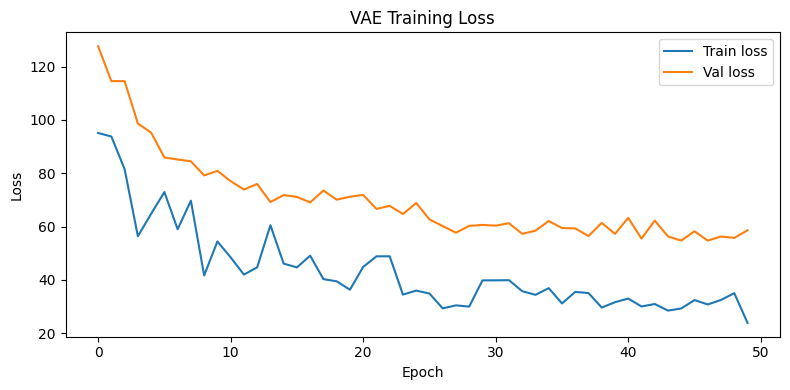

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


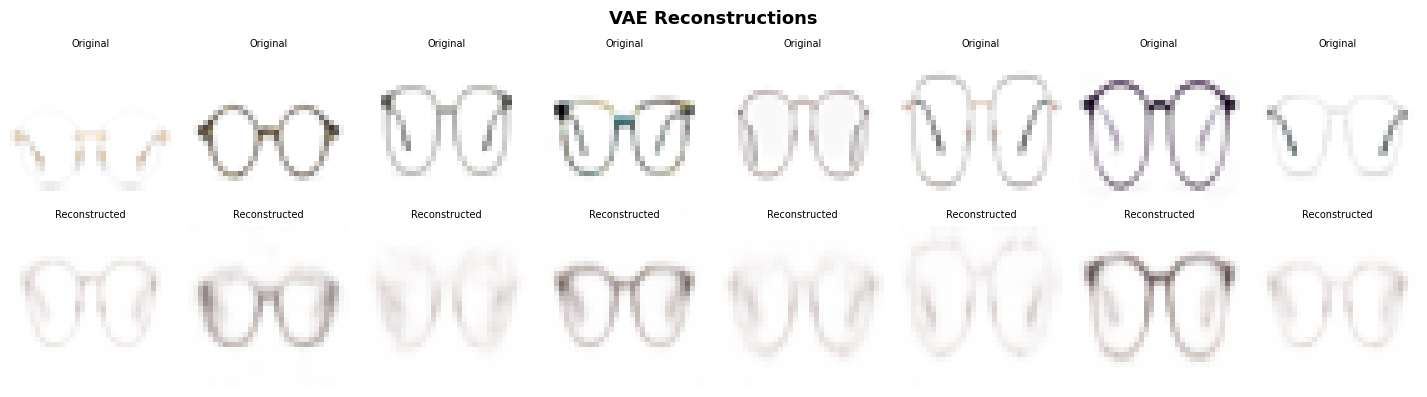

In [53]:
# Plot the curves and reconstructions
plot_loss(history, title="VAE Training Loss")
show_reconstructions(vae, X_test, n=8, title="VAE Reconstructions")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


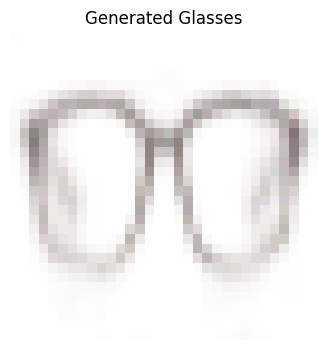

In [54]:

#Generate a new glasses image
z_sample = np.random.normal(size=(1, latent_dim)).astype(np.float32)
generated = decoder.predict(z_sample)[0]

generated_img = (generated * 255.0).clip(0, 255).astype(np.uint8)
img = Image.fromarray(generated_img)

out_file = save_path / "new_glasses.png"
img.save(out_file)

#Show it here!
plt.figure(figsize=(4,4))
plt.imshow(generated_img)
plt.axis("off")
plt.title("Generated Glasses")
plt.show()